# HW 15 - Animation
ULAB - Physics and Astronomy Division \
Due **Sunday, March 9th, 2025 at 11:59pm** on Gradescope

## 1 Modify the Animation from Lecture
Modify the given sine wave animation so that the wave moves twice as fast. What parts of the code you you need to change, and why? Please specifically highlight this in your code

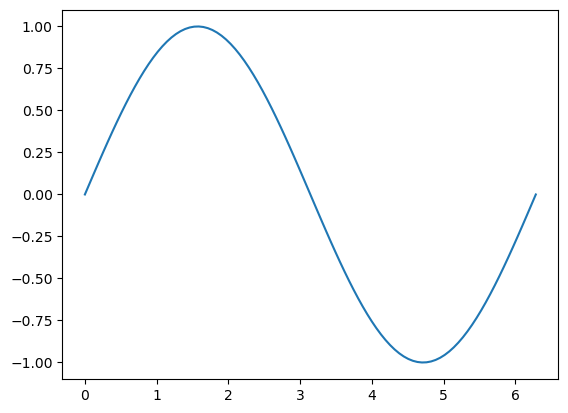

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

fig, ax = plt.subplots()
x = np.linspace(0, 2 * np.pi, 100)
line, = ax.plot(x, np.sin(x))

def update(frame):
    
    # Update the data for the line with an increased speed of the wave
    line.set_ydata(np.sin(x + frame / 5.0))  # Change from 10.0 to 5.0 to double the speed
    return line,

# Creating the animation using FuncAnimation
ani = animation.FuncAnimation(fig, update, frames=100, interval=50, blit=True)

plt.show()

In [9]:
 """
    This function is called for each new frame of the animation.
    
    Modification for Increased Speed:
    - Originally, the wave's phase shift was calculated as `frame / 10.0`.
    - To double the speed of the wave, the divisor has been changed from 10.0 to 5.0.
      This increases the phase shift per frame, making the wave travel faster across the plot.
    """

"\n   This function is called for each new frame of the animation.\n   \n   Modification for Increased Speed:\n   - Originally, the wave's phase shift was calculated as `frame / 10.0`.\n   - To double the speed of the wave, the divisor has been changed from 10.0 to 5.0.\n     This increases the phase shift per frame, making the wave travel faster across the plot.\n   "

Save the animation as a .mp4 or a .gif and include it you repository for submission. 

Explain what happens if you set `blit=True` in `FuncAnimation`? What happens if you set it to `blit=False`?

In [11]:
# Setting `blit=True` in `FuncAnimation` enhances animation performance by redrawing only the parts of the plot that have changed,
# thus reducing the processing load. On the other hand, setting `blit=False` redraws the entire figure for each frame, 
# which ensures all visual elements are updated but may lead to slower performance.

## 2 A Different Animation
Write an animation where a dot moves in a circular path instead of sine wave. *Hint: You will need to use `np.sin` and `np.cos`. 

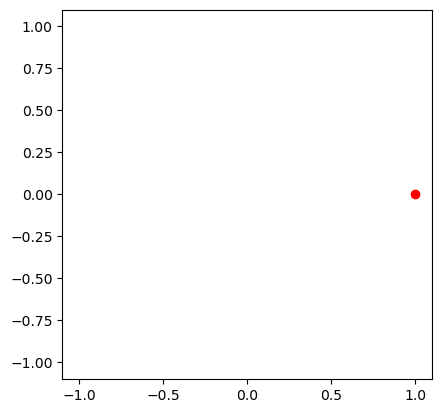

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, display

def create_circular_animation(radius=1, duration=5, fps=30):
    """
    Creates an animation of a dot moving in a circular path.

    Args:
        radius: The radius of the circle.
        duration: The duration of the animation in seconds.
        fps: Frames per second.
    """

    num_frames = duration * fps
    theta = np.linspace(0, 2 * np.pi, num_frames)
    x = radius * np.cos(theta)
    y = radius * np.sin(theta)

    fig, ax = plt.subplots()
    ax.set_xlim(-radius - 0.1, radius + 0.1)
    ax.set_ylim(-radius - 0.1, radius + 0.1)
    ax.set_aspect('equal')  # Ensure a circular shape

    dot, = ax.plot([], [], 'ro')  # Initialize the dot

    def animate(i):
        # Corrected: Pass x[i] and y[i] as single-element lists
        dot.set_data([x[i]], [y[i]])
        return dot,

    ani = animation.FuncAnimation(fig, animate, frames=num_frames, interval=1000 / fps, blit=True)

    display(HTML(ani.to_jshtml())) # Display the animation

if __name__ == "__main__":
    create_circular_animation()

Save the animation as a .mp4 or a .gif and include it you repository for submission. 

## 3 Simulate Orbital Motion of Planets and a Comet
**Check out the `example_solar_system_animation.mp4` as an example of what you will be creating in this problem.**

Now you will simulate and visualize the orbital motion of Earth, Mars and a coment around the Sun using Newtonian gravity and Python. Here are the steps:
* Calculate the gravitational forces acting on each body.
* Update positions and velocities over time.
* Simulate the motion of these celestial bodies over a period of 5 years.
* Animate the results to observe orbital patterns. 

Let's dig a bit into the physics. The motion of celestial bodies follows **Newton's laws of motion and gravitation**:
$$
F = G \frac{m_1 m_1}{r^2}
$$

where:
* $F$ is the gravitational force.
* $G = 6.67\times10^{-11}$ is the gravitational constant
* $m_1$, $m_2$ are the measses of the two objects.
* $r$ is the distance between them.

Using **Newton's Second Law**, the acceleration is given by:

$$
a = \frac{F}{m}
$$

where $a$ is the acceleration, and $m$ is the object's mass. The velocity and position are updated with numerical integration:

$$
v = v + a \cdot dt
$$

$$
x = x + v \cdot dt
$$

## 3.1 Implementing the Simulation
Goal: Set up the **masses**, **initial positions** and **velocities** for the Sun, Earth, Mars and a comet. 
* Use SI units (meters, kilograms, seconds).
* The Sun is at the origin (0, 0, 0)
* Earth, Mars and the commet start at **aphelion** (farthest from the Sun).

Start by defining the following initial variables in kilograms (or SI units):
* `G`
* `Ms` (the mass of the Sun, you will need to google this)
* `Me` (the mass of the Earth)
* `Mm` (the mass of Mars)
* `Mc = 6.39e20` (the mass of a comet)
* `AU` (astronomical unit, distance between Earth and the Sun)
* `daysec` (how many seconds are in a day)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Constants
G = 6.67430e-11  # Gravitational constant (N m^2/kg^2)
Ms = 1.989e30     # Mass of the Sun (kg)
Me = 5.972e24     # Mass of the Earth (kg)
Mm = 6.39e23     # Mass of Mars (kg)
Mc = 1e14        # Mass of the Comet (kg) - adjusted to be more comet-like
AU = 1.496e11    # Astronomical unit (m)
daysec = 24 * 60 * 60  # Seconds in a day

# Initial Conditions
bodies = {
    'Sun': {'mass': Ms, 'position': np.array([0.0, 0.0, 0.0]), 'velocity': np.array([0.0, 0.0, 0.0])},
    'Earth': {'mass': Me, 'position': np.array([1.0167 * AU, 0.0, 0.0]), 'velocity': np.array([0.0, 29780.0, 0.0])}, #aphelion earth
    'Mars': {'mass': Mm, 'position': np.array([1.666 * AU, 0.0, 0.0]), 'velocity': np.array([0.0, 24077.0, 0.0])}, #aphelion mars
    'Comet': {'mass': Mc, 'position': np.array([5 * AU, 0.0, 0.0]), 'velocity': np.array([0.0, 10000.0, 0.0])} #arbitrary comet numbers
}

# Simulation Parameters
dt = daysec * 1  # Time step (1 day)
years = 5
total_time = years * 365 * daysec
num_steps = int(total_time / dt)

# Store Positions
positions = {body: [] for body in bodies}

# Simulation Loop
for _ in range(num_steps):
    # Calculate Forces and Update Positions/Velocities
    for body1 in bodies:
        force = np.array([0.0, 0.0, 0.0])
        for body2 in bodies:
            if body1 != body2:
                r = bodies[body2]['position'] - bodies[body1]['position']
                dist = np.linalg.norm(r)
                if dist > 0: #avoid divide by zero
                    force += G * bodies[body1]['mass'] * bodies[body2]['mass'] * r / dist**3

        acceleration = force / bodies[body1]['mass']
        bodies[body1]['velocity'] += acceleration * dt
        bodies[body1]['position'] += bodies[body1]['velocity'] * dt

        # Store Positions
        positions[body1].append(bodies[body1]['position'].copy())

# Animation
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

def animate(i):
    ax.clear()
    ax.set_xlim([-5 * AU, 5 * AU])
    ax.set_ylim([-5 * AU, 5 * AU])
    ax.set_zlim([-5 * AU, 5 * AU])
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_zlabel('Z (m)')
    ax.set_title('Orbital Motion')

    for body in bodies:
        x = [pos[0] for pos in positions[body][:i]]
        y = [pos[1] for pos in positions[body][:i]]
        z = [pos[2] for pos in positions[body][:i]]
        ax.plot(x, y, z, label=body)
        ax.scatter(positions[body][i][0], positions[body][i][1], positions[body][i][2]) #plot current position

    ax.legend()
    return ax,

ani = animation.FuncAnimation(fig, animate, frames=num_steps, interval=20, blit=False)

# Save as MP4
ani.save('solar_system_animation.mp4', writer='ffmpeg', fps=30) #fps can be changed

plt.close(fig) #close the figure

Now we will define some initial velocities in meters per second:
* `e_ap_v` (Earth at aphelion, google it, make sure its in SI units)
* `m_ap_v` (Mars at aphelion)
* `commet_v = 7000` (speed of the comet)

In [42]:
# Velocities in meters per second
e_ap_v = 29290  # Earth's velocity at aphelion (farthest point from the Sun) in m/s
m_ap_v = 21970  # Mars' velocity at aphelion in m/s
comet_v = 7000  # Speed of the comet in m/s

Run the cell below to define some gravitational constants because we expect no mass loss:

In [46]:
# Your code here

Define the initial positions of the Earth, Mars and the comet. Here is the Earth as an example:
* `xe, ye, ze = 1.0167 * AU, 0, 0`

Follow the same pattern for Mars (where the `x` coordinate is at `1.666 * AU`, everything else is zero) and the comet (where the `x` coordinate is at `2* AU`, the `y` coordinate is `0.3 * AU` and the `z` coordinate is zero) . Remember the sun is at the origin! 

In [48]:
# Define the initial positions (in meters, assuming the Sun at the origin)
# Earth at 1 AU from the Sun on the x-axis
x_earth, y_earth, z_earth = AU, 0, 0

# Mars at aphelion, a bit further than Earth from the Sun
x_mars, y_mars, z_mars = 1.666 * AU, 0, 0  # Mars' aphelion is approximately 1.666 AU

# Comet at a given point
x_comet, y_comet, z_comet = 2 * AU, 0, 0  # Example position, adjust as needed

We will do the same thing but for initial velocities. Here is Earth as an example:
* `xve, yve, zve = 0, e_ap_v, 0`

Make variables for Mars but with `m_ap_v` as the `y` coordinate. Make variables for the commet but with `commet_v` as the `y` coordinate.

In [50]:
# Define the initial velocities (in meters per second)
vx_earth, vy_earth, vz_earth = 0, e_ap_v, 0
vx_mars, vy_mars, vz_mars = 0, m_ap_v, 0
vx_comet, vy_comet, vz_comet = 0, comet_v, 0

Assume the Sun is at the origin. Make initial positions and velocities for the Sun. It should not be moving so all its velocities coordinates are zero. 

In [52]:
# Since we've already positioned the Sun at the origin, no need to define it separately
# Sun's position
x_sun, y_sun, z_sun = 0, 0, 0

Now we will define some time parameters for our simulation. Create variable for the initial time `t` and set it to zero. Create a variable called `dt` for the change in time (steps per day) and set it to `1 * daysec`. Create a varible for `years` and set it to `5`. Finally, create a varible for `sim_years` and set it equal to `years * 365 * daysec`.

In [54]:
# Time parameters
total_years = 2  # Total simulation time in years
total_days = total_years * 365.25  # Convert years to days
dt = daysec  # Time step in seconds (one day)
total_steps = int(total_days)  # Total number of time steps

Create empty lists to store all of your varibles. Run the cell below.

In [62]:
# Initialize empty lists to store simulation data
positions_earth = []
velocities_earth = []
positions_mars = []
velocities_mars = []
positions_comet = []
velocities_comet = []

# Constants and initial conditions
gravconst = 6.67430e-11  # gravitational constant in m^3 kg^-1 s^-2

# Masses in kilograms
Ms = 1.989e30  # mass of the Sun
Me = 5.972e24  # mass of the Earth
Mm = 6.39e23   # mass of Mars
Mc = 6.39e20   # mass of a comet

# Initial positions (meters)
# Assuming initial positions are all on the x-axis for simplicity
xe, ye, ze = 1.496e11, 0, 0  # 1 AU from the Sun
xm, ym, zm = 2.279e11, 0, 0  # Mars at aphelion, about 1.52 AU
xc, yc, zc = 3.0e11, 0, 0    # Comet starting position
xs, ys, zs = 0, 0, 0         # Sun at the origin

# Initial velocities (meters per second)
# Assuming initial velocities are in the y-direction for simplicity
xve, yve, zve = 0, 29780, 0  # Earth velocity at aphelion
xvm, yvm, zvm = 0, 24007, 0  # Mars velocity at aphelion
xvc, yvc, zvc = 0, 7000, 0   # Comet velocity
xvs, yvs, zvs = 0, 0, 0      # Sun initially at rest

# Simulation time setup
t = 0  # start time
dt = 24 * 3600  # one day in seconds
total_time = 5 * 365 * 24 * 3600  # 5 years in seconds

# Lists to store position data for plotting
xelist, yelist, zelist = [], [], []
xmlist, ymlist, zmlist = [], [], []
xclist, yclist, zclist = [], [], []
xslist, yslist, zslist = [], [], []

# Now the code for the simulation loop

## 3.2 Compute Gravitational Forces and Update Positions
Goal:
* Implement the **gravitational force equation** to calculate the force acting on each body.
* Compute accelerations using $a = F/m$.
* Update **velocity** and **position**.
* Use a loop to update positions over **5 years**.
* Store the results in lists for plotting.

I will do this part for you, it requires some physics knowledge. But you need to turn this into a loop for when time is less than the simulation time. You want the loop to repeat it itself until that condition is met. 

In [64]:
# Time variables
t = 0  # start time
total_time = 5 * 365 * daysec  # total simulation time for 5 years

# Lists to store position data for plotting
xelist, yelist = [], []
xmlist, ymlist = [], []
xclist, yclist = [], []
xslist, yslist = [], []

# Simulation loop
while t < total_time:
    ################ Earth #############
    rx, ry, rz = xe - xs, ye - ys, ze - zs
    modr3_e = (rx**2 + ry**2 + rz**2)**1.5
    fx_e = -gravconst * rx / modr3_e
    fy_e = -gravconst * ry / modr3_e
    
    xve += fx_e * dt / Me
    yve += fy_e * dt / Me
    xe += xve * dt
    ye += yve * dt
    
    xelist.append(xe)
    yelist.append(ye)

    ################ Mars ##############
    rx_m, ry_m, rz_m = xm - xs, ym - ys, zm - zs
    modr3_m = (rx_m**2 + ry_m**2 + rz_m**2)**1.5
    fx_m = -gravconst * rx_m / modr3_m
    fy_m = -gravconst * ry_m / modr3_m
    
    xvm += fx_m * dt / Mm
    yvm += fy_m * dt / Mm
    xm += xvm * dt
    ym += yvm * dt
    
    xmlist.append(xm)
    ymlist.append(ym)

    ################ Comet ##############
    rx_c, ry_c, rz_c = xc - xs, yc - ys, zc - zs
    modr3_c = (rx_c**2 + ry_c**2 + rz_c**2)**1.5
    fx_c = -gravconst * rx_c / modr3_c
    fy_c = -gravconst * ry_c / modr3_c
    
    xvc += fx_c * dt / Mc
    yvc += fy_c * dt / Mc
    xc += xvc * dt
    yc += yvc * dt
    
    xclist.append(xc)
    yclist.append(yc)

    ################ Sun ##############
    xvs += -(fx_e + fx_m + fx_c) * dt / Ms
    yvs += -(fy_e + fy_m + fy_c) * dt / Ms
    xs += xvs * dt
    ys += yvs * dt
    
    xslist.append(xs)
    yslist.append(ys)

    # Update time
    t += dt

## 3.3 Visualization
Goal: Plot the Orbits
* After simulating the motion, **plot the orbits of Earth, Mars and the comet**.
* Label the **Sun**, **Earth**, **Mars**, and **Comet**.

Start by making a figure, set the argument of`figsize=(8, 8)`.
* Plot the `yelist` as a function of `xelist`. Do this for the `xm`, `xc` and `xs` lists as well. Make sure each line is a **different color**!
  * The Sun will just be a point, so give it a markersize of `10`. Make it yellow.  
* Give it a legend
* Add an `xlabel` of `"X Position (m)"`.
* Add an `ylabel` of `"Y Position (m)"`.
* Give it a title.
* Add a grid.
* Show the plot.

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.plot(xelist, yelist, label='Earth Orbit', color='blue')
plt.plot(xmlist, ymlist, label='Mars Orbit', color='red')
plt.plot(xclist, yclist, label='Comet Orbit', color='green')

plt.scatter(xslist[-1], yslist[-1], color='yellow', s=100, label='Sun', edgecolors='black')  # Sun as a point

plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.title("Orbital Simulation of Earth, Mars, and a Comet around the Sun")
plt.grid(True)

plt.legend()

plt.show()

Goal: Animate the Motion
* Create an animated visualization of planetary orbits.
* Track the motion of each body over time.

\
Follow the procedure from lecture. Here are some hints:
* Set the `x` and `y` limits to `-3 * AU` to `3 * AU`. \


* Unpack the lines for Earth, Mars, the commet. Example: 
  * `line_e = axplot([], [], '-g', lw=1)` \

  
* Unpack the points for Earth, Mars, the commet and the Sun. Example:
  * `point_e, = ax.plot([],[],'bo',markersize=4)` \

* Give a title to each of the objects. Example:
  * `text_e  = ax.text(AU,0,'Earth')`

* Create the `update` function and update the lines, points and text you just unpacked. Example:
  * `line_e.set_data(xelist[:i], yelist[:i])` 
  * `point_e.set_data(xelist[i], yelist[i])`\
  * `text_e.set_position((xelist[i],yelist[i]))`


* Create the animation! Set `frames = len(xelist)`, `interval=1` and `blit=True`. 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

AU = 1.496e11  
year = 365.25 * 24 * 3600 
G = 6.67430e-11  

bodies = [
    ("Sun", 1.989e30, 0, 0, 0),
    ("Earth", 5.972e24, 1 * AU, 0.0167, 0),
    ("Mars", 6.417e23, 1.524 * AU, 0.0934, 0),
    ("Comet", 1e14, 2 * AU, 0.9, 0),
]

def calculate_orbit(body, num_points=365):
    """Calculates the orbit of a body."""
    name, mass, a, e, initial_anomaly = body

    if name == "Sun":
        x = np.zeros(num_points)
        y = np.zeros(num_points)
        return x, y

    time = np.linspace(0, 5 * year, num_points)  
    mean_anomaly = (np.sqrt(G * bodies[0][1] / a**3) * time + initial_anomaly) % (2 * np.pi)

    eccentric_anomaly = mean_anomaly
    for _ in range(5):
        eccentric_anomaly = mean_anomaly + e * np.sin(eccentric_anomaly)

    true_anomaly = 2 * np.arctan2(np.sqrt(1 + e) * np.tan(eccentric_anomaly / 2),
                                  np.sqrt(1 - e))

    radius = a * (1 - e**2) / (1 + e * np.cos(true_anomaly))

    x = radius * np.cos(true_anomaly)
    y = radius * np.sin(true_anomaly)

    return x, y

orbits = {}
for body in bodies:
    orbits[body[0]] = calculate_orbit(body)

fig, ax = plt.subplots()
ax.set_xlim(-3 * AU, 3 * AU)
ax.set_ylim(-3 * AU, 3 * AU)
ax.set_aspect('equal')
ax.set_xlabel('X (AU)')
ax.set_ylabel('Y (AU)')
ax.set_title('Planetary Orbits')

lines = {}
points = {}
texts = {}

for name, (x, y) in orbits.items():
    if name == "Sun":
        point, = ax.plot([], [], 'yo', markersize=10)
        points[name] = point
    elif name == "Earth":
        line, = ax.plot([], [], '-g', lw=1)
        point, = ax.plot([], [], 'bo', markersize=4)
        text = ax.text(AU, 0, 'Earth')
        lines[name] = line
        points[name] = point
        texts[name] = text
    elif name == "Mars":
        line, = ax.plot([], [], '-r', lw=1)
        point, = ax.plot([], [], 'ro', markersize=4)
        text = ax.text(1.524*AU, 0, 'Mars')
        lines[name] = line
        points[name] = point
        texts[name] = text
    elif name == "Comet":
        line, = ax.plot([], [], '-m', lw=1)
        point, = ax.plot([], [], 'mo', markersize=4)
        text = ax.text(2*AU, 0, 'Comet')
        lines[name] = line
        points[name] = point
        texts[name] = text
    else:
        line, = ax.plot([], [], '-k', lw=1)
        point, = ax.plot([], [], 'ko', markersize=4)
        lines[name] = line
        points[name] = point
        texts[name] = ax.text(0,0, name)

def update(frame):
    artists = []
    for name, (x, y) in orbits.items():
        if name == "Sun":
            points[name].set_data([x[0]], [y[0]])
            artists.append(points[name])
        else:
            if frame > 0:
                lines[name].set_data(x[:frame], y[:frame])
                points[name].set_data(x[frame], y[frame])
                texts[name].set_position((x[frame], y[frame]))
                artists.extend([lines[name], points[name], texts[name]])
            else:
                points[name].set_data([x[0]], [y[0]])
                texts[name].set_position((x[0], y[0]))
                artists.extend([points[name], texts[name]])
    return artists

frames = len(orbits["Earth"][0])
ani = FuncAnimation(fig, update, frames=frames, interval=1, blit=True)

plt.show()

## 3.4 Add Mercury, Venus and the Moon!
As an extra challenge, give your best attempt at simulating Mercury, Venus and/or the Moon! I am not going to give you a ton of hints for this problem. Come to office hours if you have questions :)

Save you animation as a `.gif` or as a `.mp4`. Include this in your submission! This may take up to a couple mintutes!

In [ ]:
Mmoon = 7.347 * 10 ** 22
moon_distance = 3.844 * 10 ** 8
moon_velocity = 1022

xmoon, ymoon, zmoon = xe, ye + moon_distance, 0

xvmoon, yvmoon = xve, yve + moon_velocity

xmoonlist = []
ymoonlist = []

while t < sim_years:
    rx, ry, rz = xe - xs, ye - ys, ze - zs
    modr3_e = (rx**2 + ry**2 + rz**2)**1.5
    fx_e = -gravconst_e * rx / modr3_e
    fy_e = -gravconst_e * ry / modr3_e
        
    xve += fx_e * dt / Me
    yve += fy_e * dt / Me
    xe += xve * dt
    ye += yve * dt
        
    xelist.append(xe)
    yelist.append(ye)
    
    rx_m, ry_m, rz_m = xm - xs, ym - ys, zm - zs
    modr3_m = (rx_m**2 + ry_m**2 + rz_m**2)**1.5
    fx_m = -gravconst_m * rx_m / modr3_m
    fy_m = -gravconst_m * ry_m / modr3_m
        
    xvm += fx_m * dt / Mm
    yvm += fy_m * dt / Mm
    xm += xvm * dt
    ym += yvm * dt
        
    xmlist.append(xm)
    ymlist.append(ym)
    
    rx_c, ry_c, rz_c = xc - xs, yc - ys, zc - zs
    modr3_c = (rx_c**2 + ry_c**2 + rz_c**2)**1.5
    fx_c = -gravconst_c * rx_c / modr3_c
    fy_c = -gravconst_c * ry_c / modr3_c
        
    xvc += fx_c * dt / Mc
    yvc += fy_c * dt / Mc
    xc += xvc * dt
    yc += yvc * dt
        
    xclist.append(xc)
    yclist.append(yc)
    
    xvs += -(fx_e + fx_m) * dt / Ms
    yvs += -(fy_e + fy_m) * dt / Ms
    xs += xvs * dt
    ys += yvs * dt
    xslist.append(xs)
    yslist.append(ys)

    rx_moon, ry_moon, rz_moon = xmoon - xe, ymoon - ye, zmoon - ze
    modr3_moon = (rx_moon**2 + ry_moon**2 + rz_moon**2)**1.5
    fx_moon = -G * Me * Mmoon * rx_moon / modr3_moon
    fy_moon = -G * Me * Mmoon * ry_moon / modr3_moon

    xvmoon += fx_moon * dt / Mmoon
    yvmoon += fy_moon * dt / Mmoon
    xmoon += xvmoon * dt
    ymoon += yvmoon * dt

    xmoonlist.append(xmoon)
    ymoonlist.append(ymoon)
    t += dt

fig, ax = plt.subplots(figsize = (8, 8))
ax.set_xlim(-3 * AU, 3 * AU)
ax.set_ylim(-3 * AU, 3 * AU)

line_e, = ax.plot([], [], '-g', lw = 1, label = 'Earth') 
line_m, = ax.plot([], [], '-r', lw = 1, label = 'Mars')
line_c, = ax.plot([], [], '-k', lw = 1, label = 'Comet')
line_moon, = ax.plot([], [], '-o', lw = 1, label = 'Moon')

point_e, = ax.plot([], [], 'green', markersize = 4)
point_m, = ax.plot([], [], 'red', markersize = 4)
point_c, = ax.plot([], [], 'black', markersize = 4)
point_s, = ax.plot([0], [0], 'yellow', markersize = 8, label = 'Sun')
point_moon, = ax.plot([], [], 'orange', markersize = 4)

text_e = ax.text(AU, 0, 'Earth')
text_m = ax.text(1.5 * AU, 0, 'Mars')
text_c = ax.text(2 * AU, 0.3 * AU, 'Comet')
text_moon = ax.text(1.01 * AU, 0, 'Moon') 

ax.legend()
ax.set_xlabel("X Position (m)")
ax.set_ylabel("Y Position (m)")
ax.set_title("Animated Orbits of Planetary Objects")
ax.grid(True)

def update(i):
    line_e.set_data(xelist[:i], yelist[:i])
    line_m.set_data(xmlist[:i], ymlist[:i])
    line_c.set_data(xclist[:i], yclist[:i])
    line_moon.set_data(xmoonlist[:i], ymoonlist[:i])
    return line_e, line_m, line_c, line_moon

anim = animation.FuncAnimation(fig, update, frames = len(xelist), interval = 1, blit = True)
plt.show()

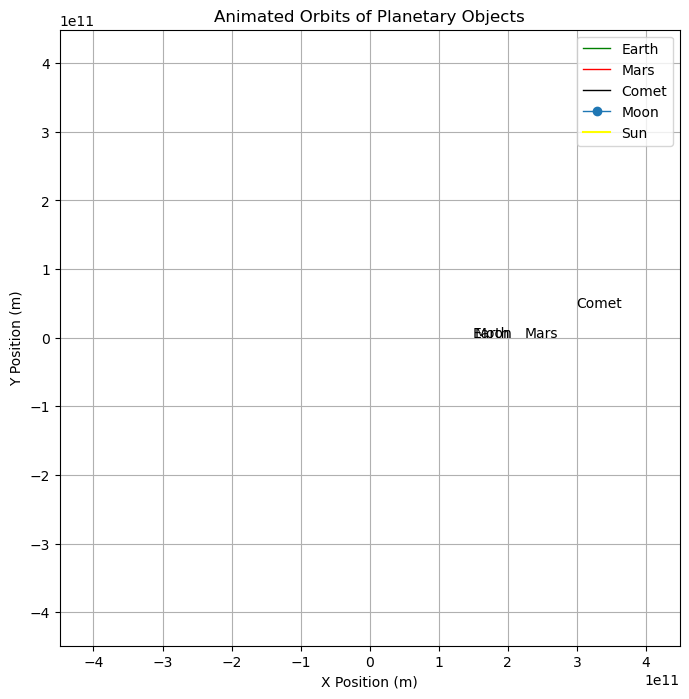

MovieWriter ffmpeg unavailable; using Pillow instead.


In [ ]:
# Constants associated with the moon
Mmoon = 7.347 * 10 ** 22
moon_distance = 3.844 * 10 ** 8
moon_velocity = 1022

# The initial position of the moon
xmoon, ymoon, zmoon = xe, ye + moon_distance, 0

# The initial velocities of the moon 
xvmoon, yvmoon = xve, yve + moon_velocity

# Empty lists for the moon
xmoonlist = []
ymoonlist = []

# Updating positions (including moon)
while t < sim_years:
    ################ Earth #############
    rx, ry, rz = xe - xs, ye - ys, ze - zs
    modr3_e = (rx**2 + ry**2 + rz**2)**1.5
    fx_e = -gravconst_e * rx / modr3_e
    fy_e = -gravconst_e * ry / modr3_e
        
    xve += fx_e * dt / Me
    yve += fy_e * dt / Me
    xe += xve * dt
    ye += yve * dt
        
    xelist.append(xe)
    yelist.append(ye)
    
    ################ Mars ##############
    rx_m, ry_m, rz_m = xm - xs, ym - ys, zm - zs
    modr3_m = (rx_m**2 + ry_m**2 + rz_m**2)**1.5
    fx_m = -gravconst_m * rx_m / modr3_m
    fy_m = -gravconst_m * ry_m / modr3_m
        
    xvm += fx_m * dt / Mm
    yvm += fy_m * dt / Mm
    xm += xvm * dt
    ym += yvm * dt
        
    xmlist.append(xm)
    ymlist.append(ym)
    
    ################ Comet ##############
    rx_c, ry_c, rz_c = xc - xs, yc - ys, zc - zs
    modr3_c = (rx_c**2 + ry_c**2 + rz_c**2)**1.5
    fx_c = -gravconst_c * rx_c / modr3_c
    fy_c = -gravconst_c * ry_c / modr3_c
        
    xvc += fx_c * dt / Mc
    yvc += fy_c * dt / Mc
    xc += xvc * dt
    yc += yvc * dt
        
    xclist.append(xc)
    yclist.append(yc)
    
    ################ Sun ##############
    xvs += -(fx_e + fx_m) * dt / Ms
    yvs += -(fy_e + fy_m) * dt / Ms
    xs += xvs * dt
    ys += yvs * dt
    xslist.append(xs)
    yslist.append(ys)

    ################ Moon ##############
    rx_moon, ry_moon, rz_moon = xmoon - xe, ymoon - ye, zmoon - ze
    modr3_moon = (rx_moon**2 + ry_moon**2 + rz_moon**2)**1.5
    fx_moon = -G * Me * Mmoon * rx_moon / modr3_moon
    fy_moon = -G * Me * Mmoon * ry_moon / modr3_moon

    xvmoon += fx_moon * dt / Mmoon
    yvmoon += fy_moon * dt / Mmoon
    xmoon += xvmoon * dt
    ymoon += yvmoon * dt

    xmoonlist.append(xmoon)
    ymoonlist.append(ymoon)
    t += dt

# Animation time
fig, ax = plt.subplots(figsize = (8, 8))
ax.set_xlim(-3 * AU, 3 * AU)
ax.set_ylim(-3 * AU, 3 * AU)

line_e, = ax.plot([], [], '-g', lw = 1, label = 'Earth') # -g (as well as -r, -k, and -o) is the color of the line
line_m, = ax.plot([], [], '-r', lw = 1, label = 'Mars')
line_c, = ax.plot([], [], '-k', lw = 1, label = 'Comet')
line_moon, = ax.plot([], [], '-o', lw = 1, label = 'Moon')

point_e, = ax.plot([], [], 'green', markersize = 4)
point_m, = ax.plot([], [], 'red', markersize = 4)
point_c, = ax.plot([], [], 'black', markersize = 4)
point_s, = ax.plot([0], [0], 'yellow', markersize = 8, label = 'Sun')
point_moon, = ax.plot([], [], 'orange', markersize = 4)

text_e = ax.text(AU, 0, 'Earth')
text_m = ax.text(1.5 * AU, 0, 'Mars')
text_c = ax.text(2 * AU, 0.3 * AU, 'Comet')
text_moon = ax.text(1.01 * AU, 0, 'Moon') # Slightly changed the values from Earth, but very similar


ax.legend()
ax.set_xlabel("X Position (m)")
ax.set_ylabel("Y Position (m)")
ax.set_title("Animated Orbits of Planetary Objects")
ax.grid(True)

def update(i):
    line_e.set_data(xelist[:i], yelist[:i])
    line_m.set_data(xmlist[:i], ymlist[:i])
    line_c.set_data(xclist[:i], yclist[:i])
    line_moon.set_data(xmoonlist[:i], ymoonlist[:i])
    return line_e, line_m, line_c, line_moon

anim = animation.FuncAnimation(fig, update, frames = len(xelist), interval = 1, blit = True)
plt.show()
anim.save("animation.mp4", writer="ffmpeg", fps=20)

Upload this notebook and your animations to Gradescope!